In [1]:
%pip install tensorflow opencv-python mediapipe sklearn matplotlib

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement sklearn (from versions: none)
ERROR: No matching distribution found for sklearn


In [2]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp

# 2. Keypoints using MP Holistic


In [3]:
mp_holistic = mp.solutions.holistic # Holistic model
mp_drawing = mp.solutions.drawing_utils # Drawing utilities

In [4]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR CONVERSION BGR 2 RGB
    image.flags.writeable = False                  # Image is no longer writeable
    results = model.process(image)                 # Make prediction
    image.flags.writeable = True                   # Image is now writeable
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR COVERSION RGB 2 BGR
    return image, results

In [5]:
def draw_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACE_CONNECTIONS) # Draw face connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS) # Draw pose connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw right hand connections

In [6]:
def draw_styled_landmarks(image, results):
    # Draw face connections
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACE_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1), 
                             mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
                             ) 
    # Draw pose connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                             ) #brown/purple style
    # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                             ) 
    # Draw right hand connections  
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                             ) 

In [7]:
import cv2
import mediapipe as mp
import numpy as np

mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils


def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = model.process(image)
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    return image, results


def draw_styled_landmarks(image, results):
    # Pose
    if results.pose_landmarks:
        mp_drawing.draw_landmarks(
            image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS)
    
    # Left hand
    if results.left_hand_landmarks:
        mp_drawing.draw_landmarks(
            image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS)

    # Right hand
    if results.right_hand_landmarks:
        mp_drawing.draw_landmarks(
            image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS)


def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility]
                     for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)

    lh = np.array([[res.x, res.y, res.z]
                   for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)

    rh = np.array([[res.x, res.y, res.z]
                   for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)

    return np.concatenate([pose, lh, rh])



cap = cv2.VideoCapture(0)

with mp_holistic.Holistic(min_detection_confidence=0.5,
                          min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        ret, frame = cap.read()

        image, results = mediapipe_detection(frame, holistic)

        keypoints = extract_keypoints(results)
        print(keypoints)  # <-- This prints NUMPY ARRAY of all landmarks

        draw_styled_landmarks(image, results)

        cv2.imshow('OpenCV Feed', image)

        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()


[ 5.48909187e-01  5.12091279e-01 -1.19649100e+00  9.99531865e-01
  5.77478111e-01  4.48760390e-01 -1.11844146e+00  9.99125063e-01
  5.95858932e-01  4.50897813e-01 -1.11893868e+00  9.99200523e-01
  6.14203870e-01  4.53966498e-01 -1.11923194e+00  9.98980701e-01
  5.15680850e-01  4.50390548e-01 -1.12283397e+00  9.99155283e-01
  4.93264198e-01  4.54560399e-01 -1.12231982e+00  9.99318838e-01
  4.74022925e-01  4.59532142e-01 -1.12292957e+00  9.99309659e-01
  6.37294948e-01  4.99805182e-01 -6.35132730e-01  9.99058187e-01
  4.49663252e-01  5.05997777e-01 -6.32984877e-01  9.99466598e-01
  5.82122386e-01  5.95133066e-01 -1.01634228e+00  9.99476373e-01
  5.11646211e-01  5.99212110e-01 -1.01756167e+00  9.99633551e-01
  7.88178623e-01  9.00545120e-01 -3.67492408e-01  9.87106085e-01
  3.02099138e-01  9.15465176e-01 -4.03779179e-01  9.93511140e-01
  9.17064667e-01  1.32676053e+00 -4.78894532e-01  6.13843016e-02
  1.34042978e-01  1.32681537e+00 -5.80247402e-01  3.41282815e-01
  9.17551219e-01  1.69325

In [8]:
if results.left_hand_landmarks:
    print("Left hand landmarks:", len(results.left_hand_landmarks.landmark))
else:
    print("Left hand not detected")

if results.right_hand_landmarks:
    print("Right hand landmarks:", len(results.right_hand_landmarks.landmark))
else:
    print("Right hand not detected")

if results.pose_landmarks:
    print("Pose landmarks:", len(results.pose_landmarks.landmark))
else:
    print("Pose not detected")


Left hand landmarks: 21
Right hand landmarks: 21
Pose landmarks: 33


In [9]:
results

mediapipe.python.solution_base.SolutionOutputs

In [10]:
import mediapipe as mp
mp_face_mesh = mp.solutions.face_mesh

def draw_landmarks(image, results):
    # Draw face mesh
    if results.face_landmarks:
        mp_drawing.draw_landmarks(
            image,
            results.face_landmarks,
            mp.solutions.face_mesh.FACEMESH_TESSELATION
        )

    # Draw pose
    if results.pose_landmarks:
        mp_drawing.draw_landmarks(
            image,
            results.pose_landmarks,
            mp_holistic.POSE_CONNECTIONS
        )

    # Draw left hand
    if results.left_hand_landmarks:
        mp_drawing.draw_landmarks(
            image,
            results.left_hand_landmarks,
            mp_holistic.HAND_CONNECTIONS
        )

    # Draw right hand
    if results.right_hand_landmarks:
        mp_drawing.draw_landmarks(
            image,
            results.right_hand_landmarks,
            mp_holistic.HAND_CONNECTIONS
        )


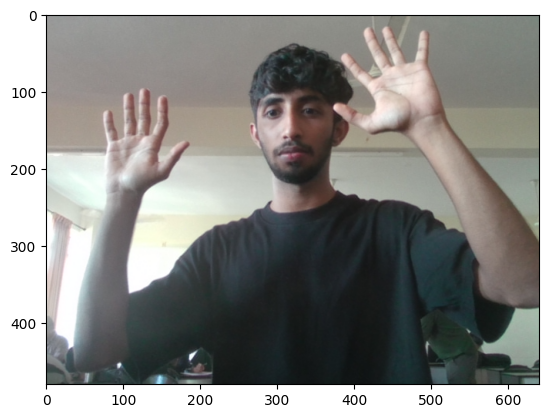

In [11]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

# 3. Extract Keypoint Values

In [12]:
def count_landmarks(landmark_obj):
    if landmark_obj is None:
        return 0
    return len(landmark_obj.landmark)


In [13]:
pose = []
for lm in results.pose_landmarks.landmark:
    test = np.array([lm.x, lm.y, lm.z, lm.visibility])
    pose.append(test)

In [14]:
pose = np.array([[lm.x, lm.y, lm.z, lm.visibility] for lm in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(132)
face = np.array([[lm.x, lm.y, lm.z] for lm in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(1404)
lh = np.array([[lm.x, lm.y, lm.z] for lm in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
rh = np.array([[lm.x, lm.y, lm.z] for lm in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)

In [15]:
face = (
    np.array([[lm.x, lm.y, lm.z] for lm in results.face_landmarks.landmark]).flatten()
    if results.face_landmarks
    else np.zeros(1404)
)


In [16]:
def extract_keypoints(results):
    pose = np.array([[lm.x, lm.y, lm.z, lm.visibility] for lm in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    face = np.array([[lm.x, lm.y, lm.z] for lm in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
    lh = np.array([[lm.x, lm.y, lm.z] for lm in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[lm.x, lm.y, lm.z] for lm in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, face, lh, rh])

In [17]:
result_test = extract_keypoints(results)

In [18]:

result_test

array([ 0.48793682,  0.2986761 , -0.87960255, ...,  0.12389001,
        0.2699315 , -0.03082069])

In [19]:
468*3+33*4+21*3+21*3
#face pose rh lh

1662

In [20]:
np.save('0', result_test)

np.load('0.npy')

# 4. Setup Folders for Collection


In [21]:
# Path for exported data, numpy arrays
DATA_PATH = os.path.join('MP_Data') 

# Actions that we try to detect
actions = np.array(['hello', 'thanks', 'iloveyou'])

# Thirty videos worth of data
no_sequences = 30

# Videos are going to be 30 frames in length
sequence_length = 30

In [22]:
# hello
## 0
## 1
## 2
## ...
## 29
# thanks

# I love you

In [23]:
for action in actions: 
    for sequence in range(no_sequences):
        try: 
            os.makedirs(os.path.join(DATA_PATH, action, str(sequence)))
        except:
            pass

# 5. Collect Keypoint Values for Training and Testing

In [24]:
cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    
    # NEW LOOP
    # Loop through actions
    for action in actions:
        # Loop through sequences aka videos
        for sequence in range(no_sequences):
            # Loop through video length aka sequence length
            for frame_num in range(sequence_length):

                # Read feed
                ret, frame = cap.read()

                # Make detections
                image, results = mediapipe_detection(frame, holistic)
                #print(results)

                # Draw landmarks
                draw_styled_landmarks(image, results)
                
                # NEW Apply wait logic
                if frame_num == 0:
                    cv2.putText(image, 'STARTING COLLECTION', (120,200), 
                               cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255, 0), 4, cv2.LINE_AA)
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15,12), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                    cv2.waitKey(2000)
                else: 
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15,12), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                
                # NEW Export keypoints
                keypoints = extract_keypoints(results)
                npy_path = os.path.join(DATA_PATH, action, str(sequence), str(frame_num))
                np.save(npy_path, keypoints)

                # Break gracefully
                if cv2.waitKey(10) & 0xFF == ord('q'):
                    break
                    
    cap.release()
    cv2.destroyAllWindows()

In [25]:
cap.release()
cv2.destroyAllWindows()

# 6. Preprocess Data and Create Labels and Features

In [26]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [27]:
label_map = {label:num for num, label in enumerate(actions)}

In [28]:
label_map

{'hello': 0, 'thanks': 1, 'iloveyou': 2}

In [29]:
print(os.path.join(DATA_PATH, action, str(sequence), "{}.npy".format(frame_num)))


MP_Data\iloveyou\29\29.npy


In [30]:
sequences, labels = [], []

for action in actions:
    for sequence in range(no_sequences):

        window = []
        valid = True

        for frame_num in range(sequence_length):
            path = os.path.join(DATA_PATH, action, str(sequence), f"{frame_num}.npy")

            if not os.path.exists(path):
                print(" Missing:", path)
                valid = False
                break   # STOP this sequence

            res = np.load(path)
            window.append(res)

        if valid:   # ONLY add if full sequence exists
            sequences.append(window)
            labels.append(label_map[action])


In [31]:
np.array(sequences).shape

(90, 30, 1662)

In [32]:
np.array(labels).shape

(90,)

In [33]:
X = np.array(sequences)

In [34]:
X.shape

(90, 30, 1662)

In [35]:
y = to_categorical(labels).astype(int)

In [36]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05)

In [37]:
y_test.shape

(5, 3)

# 7. Build and Train LSTM Neural Network

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import TensorBoard

In [39]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)

In [40]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(30,1662)))
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(LSTM(64, return_sequences=False, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(actions.shape[0], activation='softmax'))

In [41]:
res = [.7, 0.2, 0.1]

In [42]:
actions[np.argmax(res)]

'hello'

In [43]:
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

In [44]:
model.fit(X_train, y_train, epochs=2000, callbacks=[tb_callback])

Epoch 1/2000
3/3 [==============================] - 5s 79ms/step - loss: 1.2085 - categorical_accuracy: 0.3529
Epoch 2/2000
3/3 [==============================] - 0s 81ms/step - loss: 1.3152 - categorical_accuracy: 0.2588
Epoch 3/2000
3/3 [==============================] - 0s 84ms/step - loss: 1.0512 - categorical_accuracy: 0.5176
Epoch 4/2000
3/3 [==============================] - 0s 88ms/step - loss: 1.0375 - categorical_accuracy: 0.3412
Epoch 5/2000
3/3 [==============================] - 0s 83ms/step - loss: 1.1191 - categorical_accuracy: 0.4235
Epoch 6/2000
3/3 [==============================] - 0s 86ms/step - loss: 1.0105 - categorical_accuracy: 0.4353
Epoch 7/2000
3/3 [==============================] - 0s 85ms/step - loss: 0.7851 - categorical_accuracy: 0.4824
Epoch 8/2000
3/3 [==============================] - 0s 86ms/step - loss: 0.6658 - categorical_accuracy: 0.6471
Epoch 9/2000
3/3 [==============================] - 0s 86ms/step - loss: 0.6134 - categorical_accuracy: 0.6118
E

In [45]:

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 30, 64)            442112    
                                                                 
 lstm_1 (LSTM)               (None, 30, 128)           98816     
                                                                 
 lstm_2 (LSTM)               (None, 64)                49408     
                                                                 
 dense (Dense)               (None, 64)                4160      
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 3)                 99        
                                                                 
Total params: 596,675
Trainable params: 596,675
Non-trai

# 8. Make Predictions

In [46]:
# Ensure `model` is available for prediction. If it was deleted, load from saved file.
from tensorflow.keras.models import load_model
import os
if 'model' not in globals() or model is None:
    if os.path.exists('action.h5'):
        model = load_model('action.h5')
    else:
        raise FileNotFoundError("Saved model 'action.h5' not found. Train and save the model first.")

In [47]:
res = model.predict(X_test)

1/1 [==============================] - 0s 381ms/step


In [48]:
actions[np.argmax(res[4])]

'hello'

In [49]:
actions[np.argmax(res[4])]

'hello'

# 9. Save Weights

In [50]:
model.load_weights('action.h5')

# 10. Evaluation using Confusion Matrix and Accuracy

In [51]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score

In [52]:
yhat = model.predict(X_test)

1/1 [==============================] - 0s 30ms/step


In [53]:
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

In [54]:
multilabel_confusion_matrix(ytrue, yhat)

array([[[4, 0],
        [0, 1]],

       [[2, 0],
        [0, 3]],

       [[4, 0],
        [0, 1]]], dtype=int64)

In [55]:
accuracy_score(ytrue, yhat)

1.0

# 11. Test in Real Time

In [56]:
from scipy import stats

In [57]:
colors = [(245,117,16), (117,245,16), (16,117,245)]
def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()
    for num, prob in enumerate(res):
        cv2.rectangle(output_frame, (0,60+num*40), (int(prob*100), 90+num*40), colors[num], -1)
        cv2.putText(output_frame, actions[num], (0, 85+num*40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)
        
    return output_frame

In [66]:
sequence.reverse()

In [67]:
len(sequence)

30

In [68]:
sequence.append('def')

In [69]:
sequence.reverse()

In [70]:
sequence[-30:]

[array([ 0.49296823,  0.56387043, -0.9434129 , ...,  0.        ,
         0.        ,  0.        ]),
 array([ 0.49417886,  0.56396693, -0.98953563, ...,  0.        ,
         0.        ,  0.        ]),
 array([ 0.49530244,  0.56550312, -0.99282265, ...,  0.        ,
         0.        ,  0.        ]),
 array([ 0.49536601,  0.56757075, -0.95020217, ...,  0.        ,
         0.        ,  0.        ]),
 array([ 0.49578723,  0.56868714, -0.92478073, ...,  0.        ,
         0.        ,  0.        ]),
 array([ 0.49579701,  0.56938106, -0.94242984, ...,  0.        ,
         0.        ,  0.        ]),
 array([ 0.49716061,  0.57154334, -0.99142075, ...,  0.        ,
         0.        ,  0.        ]),
 array([ 0.49738646,  0.57410222, -0.97924232, ...,  0.        ,
         0.        ,  0.        ]),
 array([ 0.49944201,  0.5745284 , -0.98012447, ...,  0.        ,
         0.        ,  0.        ]),
 array([ 0.50213265,  0.57465434, -1.02478576, ...,  0.        ,
         0.        ,  0.  

In [71]:

# 1. New detection variables
sequence = []
sentence = []
threshold = 0.8

cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)
        
        # 2. Prediction logic
        keypoints = extract_keypoints(results)
#         sequence.insert(0,keypoints)
#         sequence = sequence[:30]
        sequence.append(keypoints)
        sequence = sequence[-30:]
        
        if len(sequence) == 30:
            res = model.predict(np.expand_dims(sequence, axis=0))[0]
            print(actions[np.argmax(res)])
            
            
        #3. Viz logic
            if res[np.argmax(res)] > threshold: 
                if len(sentence) > 0: 
                    if actions[np.argmax(res)] != sentence[-1]:
                        sentence.append(actions[np.argmax(res)])
                else:
                    sentence.append(actions[np.argmax(res)])

            if len(sentence) > 5: 
                sentence = sentence[-5:]

            # Viz probabilities
            image = prob_viz(res, actions, image, colors)
            
        cv2.rectangle(image, (0,0), (640, 40), (245, 117, 16), -1)
        cv2.putText(image, ' '.join(sentence), (3,30), 
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
        
        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [65]:
cap.release()
cv2.destroyAllWindows()

In [ ]:
res[np.argmax(res)] > threshold

In [59]:
model.predict(np.expand_dims(X_test[0], axis=0))
#(batch_size, sequence_length, features)


1/1 [==============================] - 0s 46ms/step


array([[8.3535618e-01, 6.5776723e-05, 1.6457807e-01]], dtype=float32)